# 🧠 Stroke Prediction — EDA & Data Processing

<div align="center">
  <img src="https://img.icons8.com/color/96/000000/brain.png" width="60"/>
</div>

<br>

<span style="font-size:1.1em;">
Este notebook reorganiza el análisis de predicción de ACV (stroke) en un flujo profesional, visual y didáctico. Se mantiene el contenido analítico, pero se mejora la presentación y claridad.
</span>

---

## 🎯 Objetivos

- **Carga y partición** del dataset en entrenamiento y validación.
- **EDA** (análisis exploratorio) solo sobre el set de entrenamiento.
- Análisis de **valores faltantes** y la categoría `"Unknown"` en `smoking_status`.
- Preprocesamiento seguro contra *leakage*.
- Construcción de matrices de features procesadas para modelado.
- Estudio de la asociación entre variables y el target usando métricas lineales y no lineales.

<br>
<details>
<summary>ℹ️ <b>Tips para navegar este notebook</b></summary>

- Las secciones están claramente marcadas y cada bloque de código incluye comentarios aclaratorios.
- Se utilizan gráficos y tablas para facilitar la interpretación.
- Al final de cada sección clave encontrarás conclusiones o recomendaciones.
</details>


## 1. ⚙️ Setup y carga de datos

> En esta sección se importan las librerías necesarias y se carga el dataset. Además, se configuran opciones visuales para que los gráficos y tablas sean más claros y agradables.


In [1]:
# ---
# 📦 Importación de librerías y configuración visual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split

# Mejoras visuales para pandas y matplotlib
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = False
sns.set_palette("Set2")  # Paleta de colores amigable
sns.set_style("whitegrid")

# ---
# 📂 Carga del dataset
default_path = Path("healthcare-dataset-stroke-data.csv")
original_path = Path(r"C:\Users\pc\OneDrive\Escritorio\EIA\2do_Bimestre\ML\datasets\healthcare-dataset-stroke-data.csv")

if default_path.exists():
    data_path = default_path
elif original_path.exists():
    data_path = original_path
else:
    raise FileNotFoundError(
        "Dataset not found. Place 'healthcare-dataset-stroke-data.csv' next to this notebook "
        "or update `data_path` manually."
    )

df = pd.read_csv(data_path)
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
# 👀 Exploración inicial del dataset
def print_section_title(title):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)

print_section_title("Dimensiones y primeras filas")
print("Dataset shape:", df.shape)
display(df.head())

print_section_title("Info de columnas")
display(df.info())

display(df.describe(include="all").T)

print_section_title("Valores faltantes por columna")
display(df.isnull().sum().sort_values(ascending=False))

print_section_title("Distribución de la variable objetivo (stroke)")
display(df["stroke"].value_counts(dropna=False).rename_axis("stroke").to_frame("count"))
display((df["stroke"].value_counts(normalize=True, dropna=False) * 100).rename_axis("stroke").to_frame("percentage"))



Dimensiones y primeras filas
Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Info de columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6



Valores faltantes por columna


bmi                  201
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
smoking_status         0
stroke                 0
dtype: int64


Distribución de la variable objetivo (stroke)


,count
stroke,
0,4861
1,249


,percentage
stroke,
0,95.127202
1,4.872798


## 2. ✂️ Train / validation split

> Se separa el dataset en entrenamiento y validación, manteniendo la proporción de la variable objetivo (*stratified split*). Esto es clave para evitar sesgos y asegurar una evaluación justa del modelo.


In [3]:
# ---
# 🔀 Split de datos en entrenamiento y validación
# Se utiliza stratify para mantener la proporción de casos de stroke en ambos sets
X = df.drop(columns="stroke")
y = df["stroke"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

split_summary = pd.DataFrame({
    "set": ["Train", "Validation"],
    "rows": [len(X_train), len(X_val)],
    "stroke_rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_val.mean() * 100, 2)
    ]
})

print("Split summary:")
display(split_summary)


Split summary:


,set,rows,stroke_rate (%)
0,Train,3577,4.86
1,Validation,1533,4.89


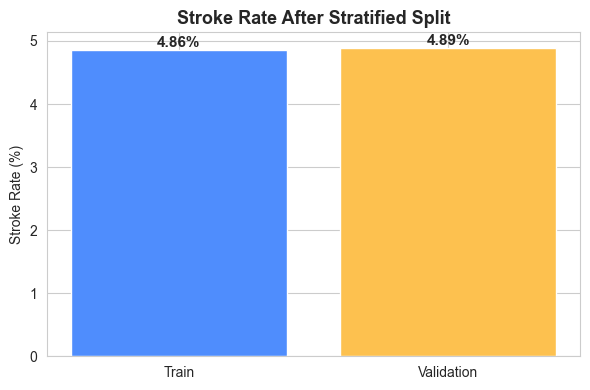


🔎 KEY OBSERVATIONS
- Train size: 3577 | Validation size: 1533
- Stroke rate (train): 4.86%
- Stroke rate (validation): 4.89%
- El split estratificado preserva la distribución de clases en ambos sets.


In [4]:
# ---
# 📊 Visualización de la proporción de stroke tras el split
plt.figure(figsize=(6, 4))

train_val_rates = [y_train.mean() * 100, y_val.mean() * 100]
labels = ["Train", "Validation"]

bars = plt.bar(labels, train_val_rates, color=["#4F8DFD", "#FDC14F"])
plt.title("Stroke Rate After Stratified Split", fontsize=13, fontweight="bold")
plt.ylabel("Stroke Rate (%)")

for bar, val in zip(bars, train_val_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🔎 KEY OBSERVATIONS")
print("=" * 60)
print(f"- Train size: {len(X_train)} | Validation size: {len(X_val)}")
print(f"- Stroke rate (train): {y_train.mean()*100:.2f}%")
print(f"- Stroke rate (validation): {y_val.mean()*100:.2f}%")
print("- El split estratificado preserva la distribución de clases en ambos sets.")


## 3. 🧩 Tipado de variables y EDA sobre entrenamiento

> Todo el análisis exploratorio se realiza **solo sobre el set de entrenamiento** para evitar *leakage* de información hacia la validación.


In [5]:
# Feature typing
num_cols = ["age", "avg_glucose_level", "bmi"]

cat_cols = [
    "gender", "hypertension", "heart_disease",
    "ever_married", "work_type", "Residence_type",
    "smoking_status"
]

print("Numerical variables:", num_cols)
print("Categorical variables:", cat_cols)

Numerical variables: ['age', 'avg_glucose_level', 'bmi']
Categorical variables: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


### 3.1 Numerical variables — distributions and outliers

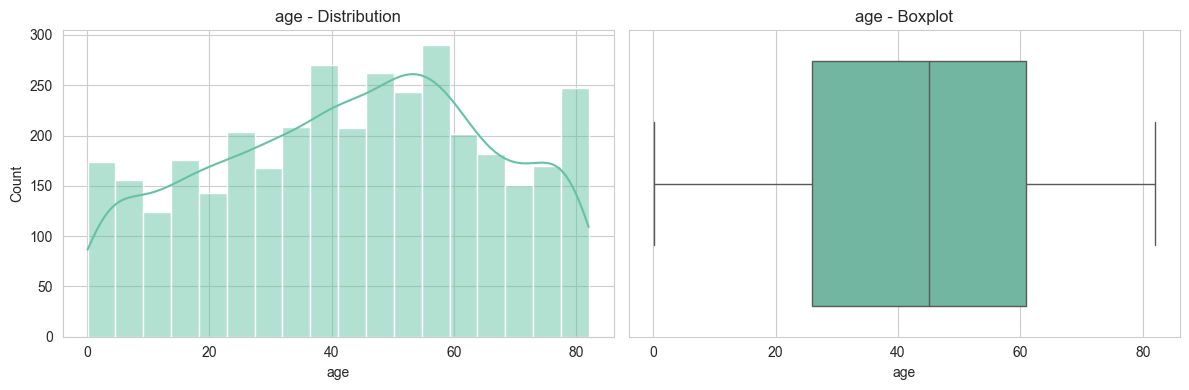

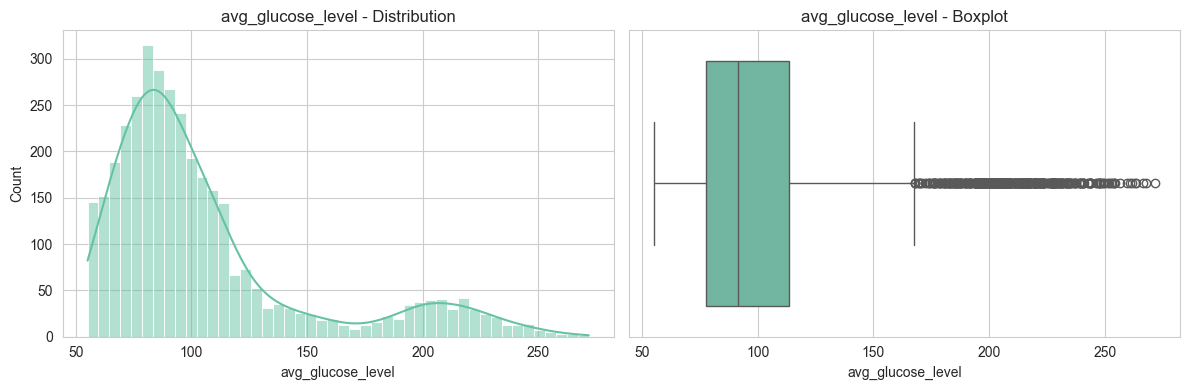

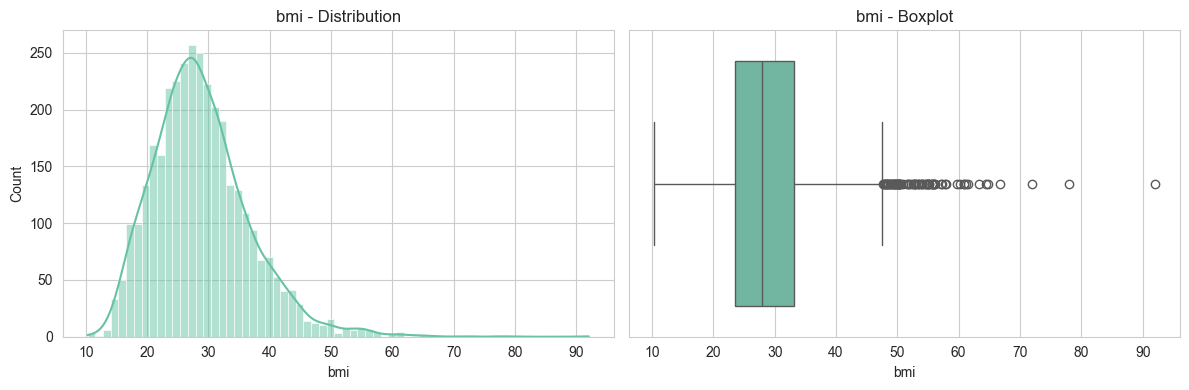

In [6]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(X_train[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} - Distribution")

    sns.boxplot(x=X_train[col], ax=axes[1])
    axes[1].set_title(f"{col} - Boxplot")

    plt.tight_layout()
    plt.show()

### 3.2 Categorical variables — distributions

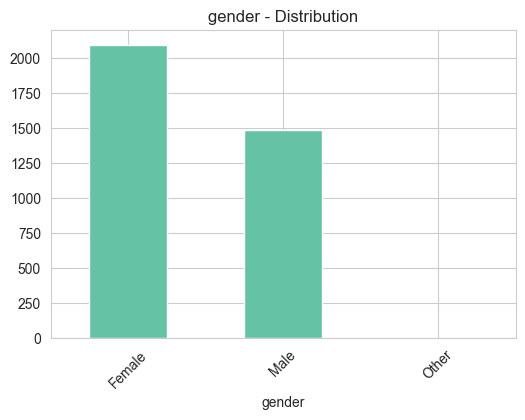

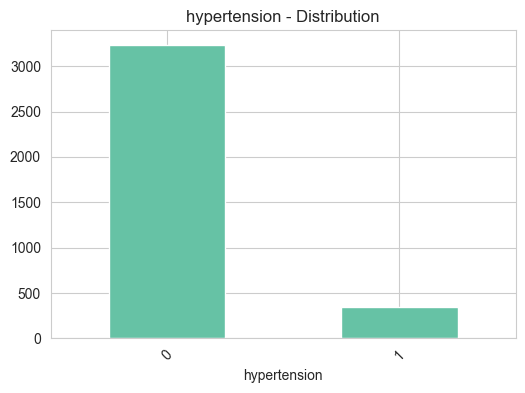

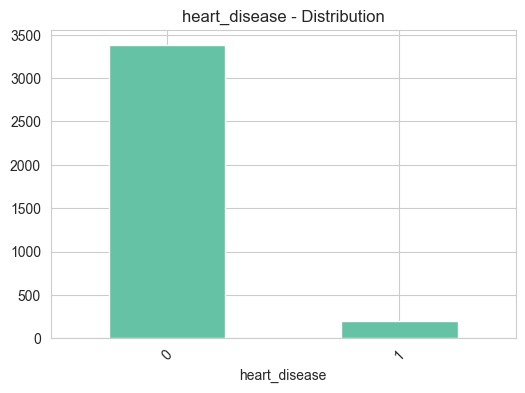

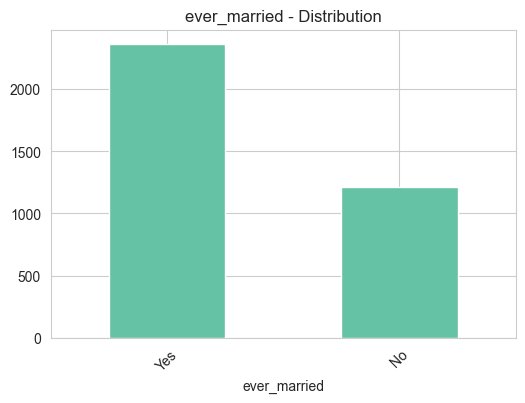

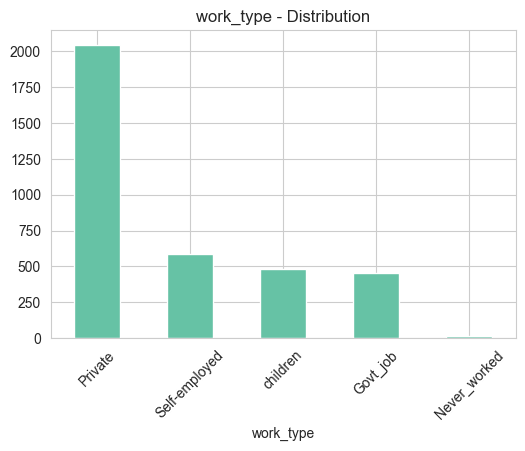

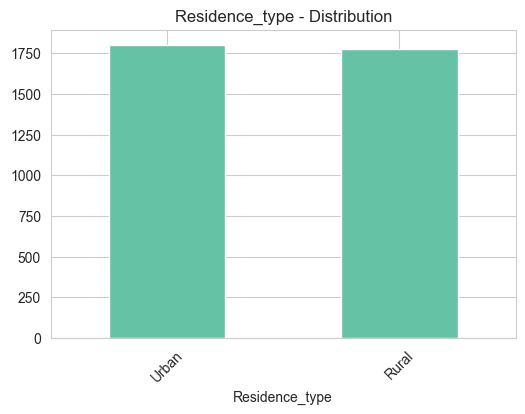

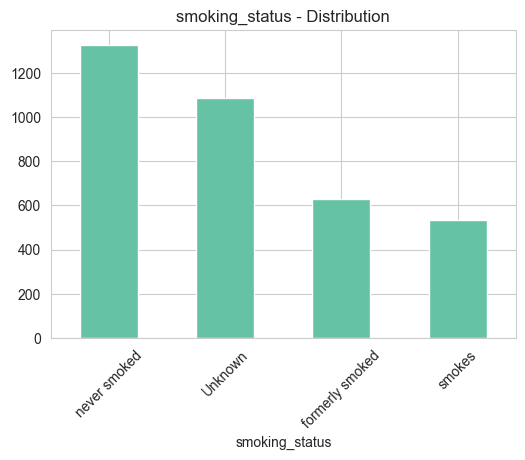

In [7]:
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    X_train[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"{col} - Distribution")
    plt.xticks(rotation=45)
    plt.show()

### 3.3 Variables vs target on the training set

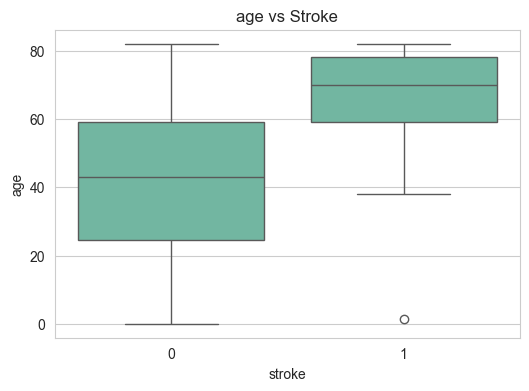

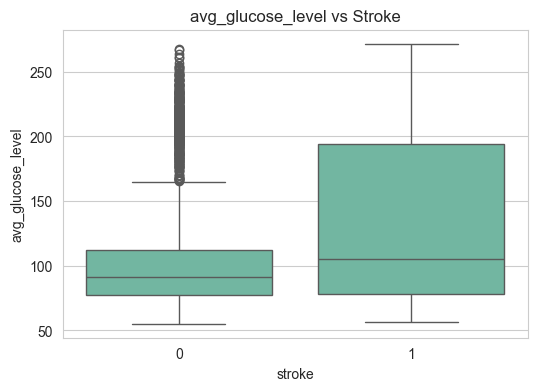

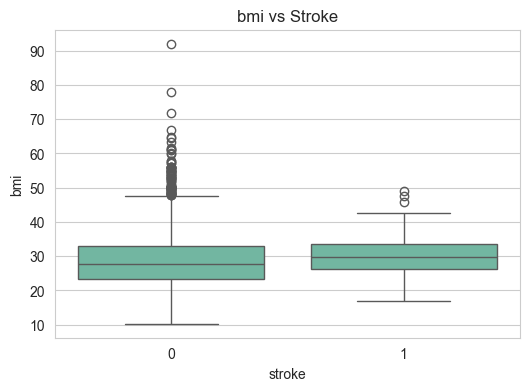

In [8]:
# Numerical vs target
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=y_train, y=X_train[col])
    plt.title(f"{col} vs Stroke")
    plt.show()

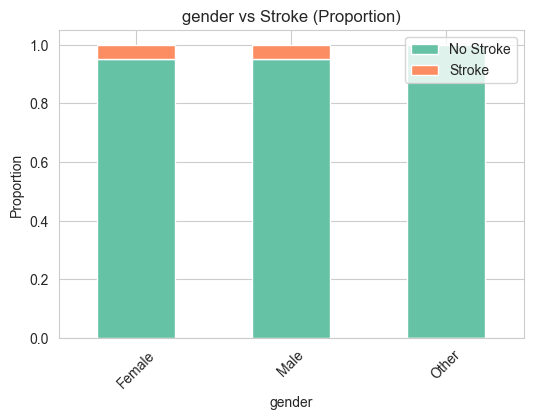

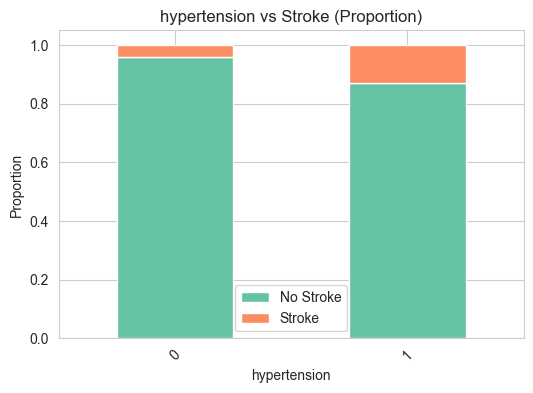

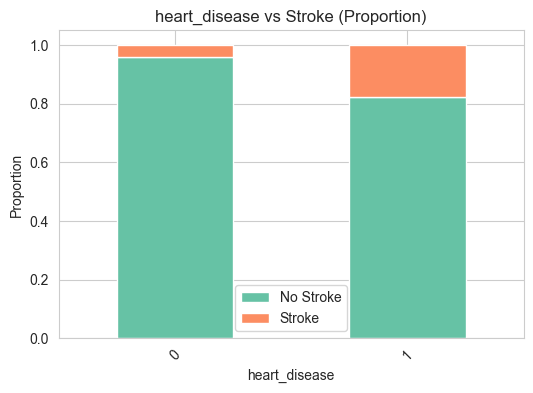

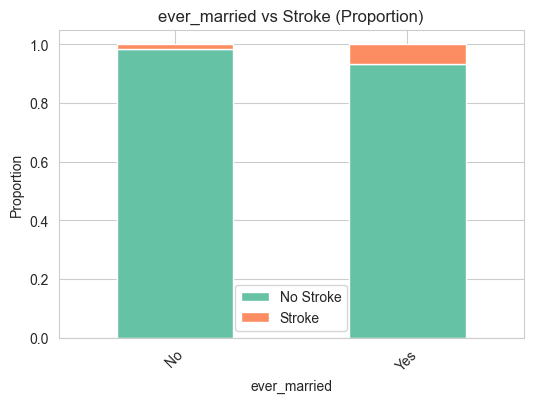

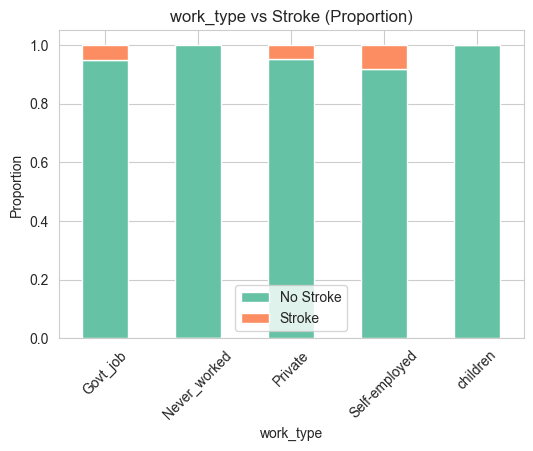

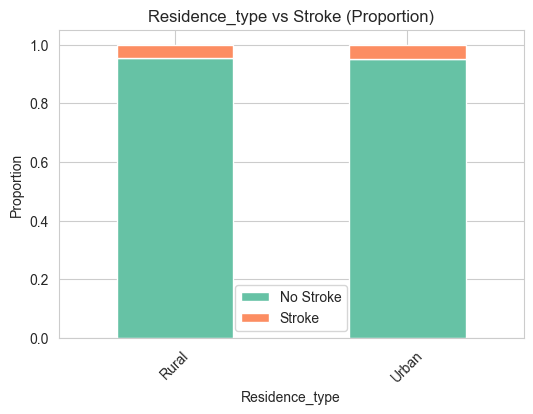

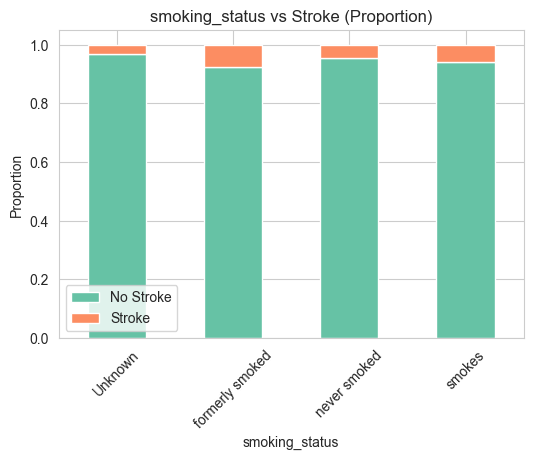

In [9]:
# Categorical vs target
for col in cat_cols:
    ctab = pd.crosstab(X_train[col], y_train, normalize="index")

    ctab.plot(kind="bar", stacked=True, figsize=(6, 4))
    plt.title(f"{col} vs Stroke (Proportion)")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.legend(["No Stroke", "Stroke"])
    plt.show()

## 4. Focused analysis of `smoking_status = "Unknown"`

This section explores whether `"Unknown"` behaves like a distinct category or could be grouped with another smoking category.


In [10]:
# Flag for unknown smoking status
X_train["smoking_unknown_flag"] = (X_train["smoking_status"] == "Unknown").astype(int)

print("Proportion of Unknown in smoking_status:")
display(X_train["smoking_unknown_flag"].value_counts(normalize=True))

Proportion of Unknown in smoking_status:


smoking_unknown_flag
0    0.696953
1    0.303047
Name: proportion, dtype: float64

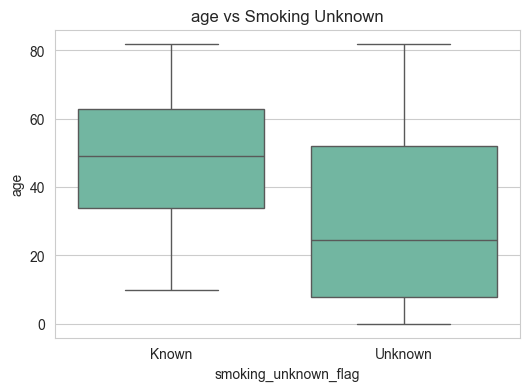

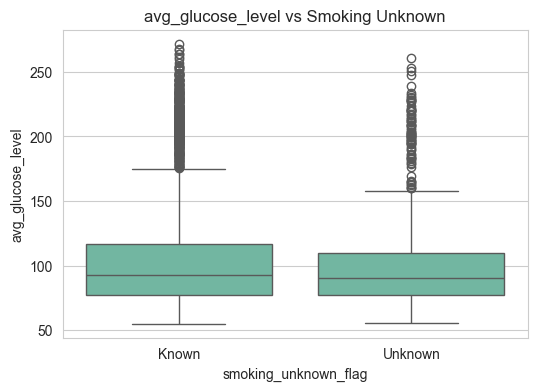

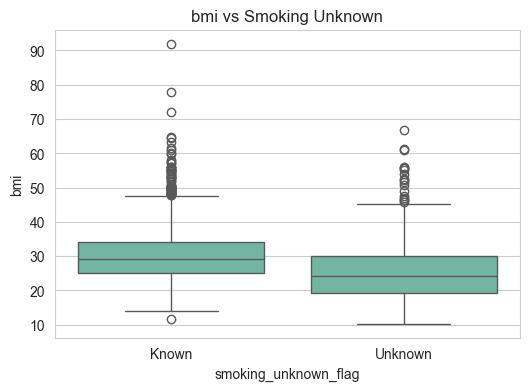

In [11]:
# Unknown vs numerical features
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=X_train["smoking_unknown_flag"], y=X_train[col])
    plt.title(f"{col} vs Smoking Unknown")
    plt.xticks([0, 1], ["Known", "Unknown"])
    plt.show()

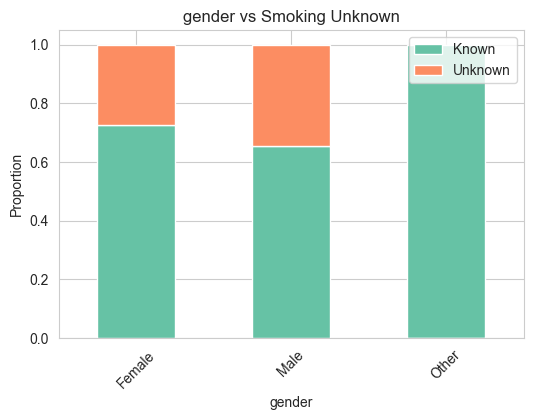

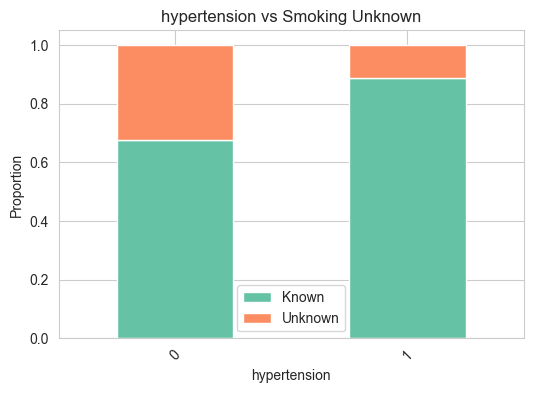

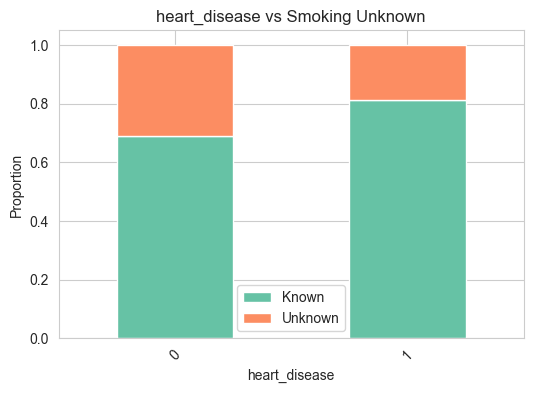

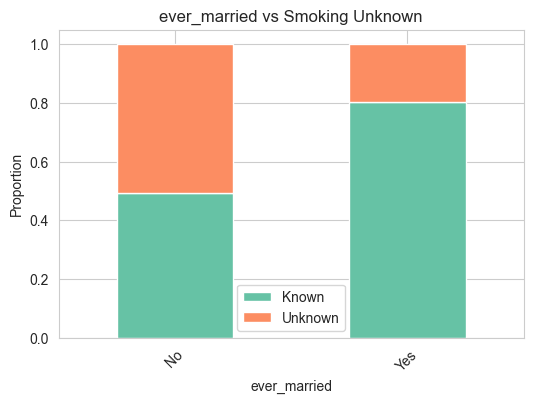

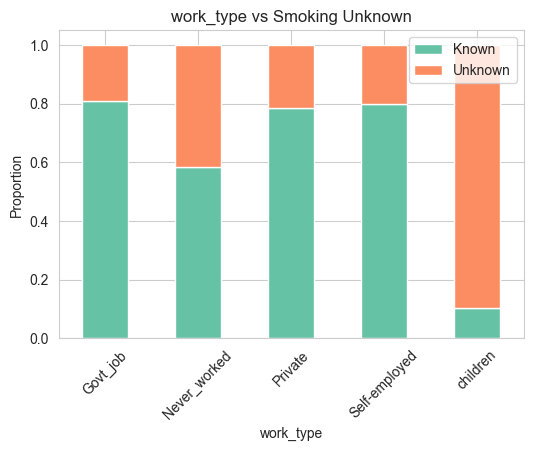

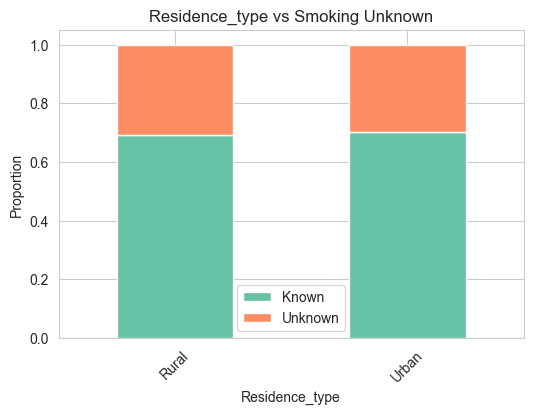

In [12]:
# Unknown vs categorical features
for col in cat_cols:
    if col != "smoking_status":
        ctab = pd.crosstab(X_train[col], X_train["smoking_unknown_flag"], normalize="index")

        ctab.plot(kind="bar", stacked=True, figsize=(6, 4))
        plt.title(f"{col} vs Smoking Unknown")
        plt.ylabel("Proportion")
        plt.xticks(rotation=45)
        plt.legend(["Known", "Unknown"])
        plt.show()

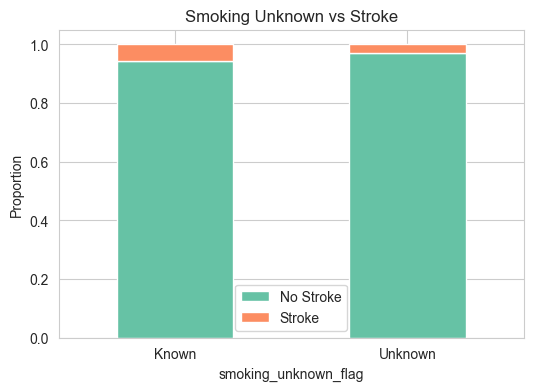

In [13]:
# Unknown vs target
ctab = pd.crosstab(X_train["smoking_unknown_flag"], y_train, normalize="index")

ctab.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.title("Smoking Unknown vs Stroke")
plt.ylabel("Proportion")
plt.xticks([0, 1], ["Known", "Unknown"], rotation=0)
plt.legend(["No Stroke", "Stroke"])
plt.show()

### Preprocessing decision for `smoking_status`

The working decision retained from the original notebook is to replace `"Unknown"` with `"never smoked"` in both training and validation sets.


In [14]:
# Smoking_status replacement
X_train["smoking_status"] = X_train["smoking_status"].replace("Unknown", "never smoked")
X_val["smoking_status"] = X_val["smoking_status"].replace("Unknown", "never smoked")

## 5. Analysis of missing values in `bmi`

In [15]:
# Missing BMI proportion
bmi_missing_rate = X_train["bmi"].isnull().mean() * 100
print(f"Missing BMI: {bmi_missing_rate:.2f}%")

Missing BMI: 4.14%


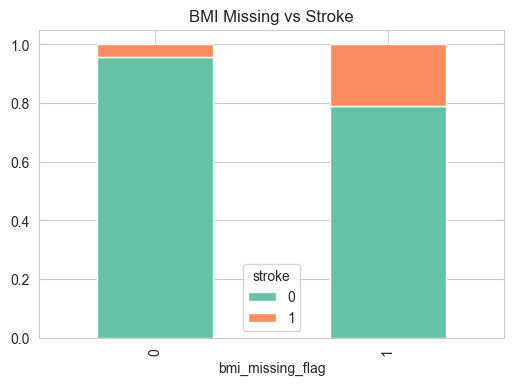

In [16]:
# Missing BMI vs target
X_train["bmi_missing_flag"] = X_train["bmi"].isnull().astype(int)

ctab = pd.crosstab(X_train["bmi_missing_flag"], y_train, normalize="index")
ctab.plot(kind="bar", stacked=True, figsize=(6, 4))
plt.title("BMI Missing vs Stroke")
plt.show()

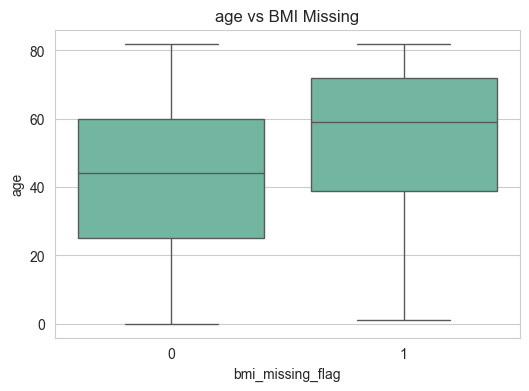

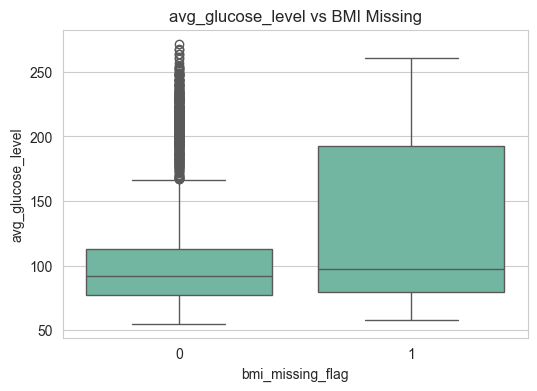

In [17]:
# Missing BMI vs selected numerical variables
for col in ["age", "avg_glucose_level"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=X_train["bmi_missing_flag"], y=X_train[col])
    plt.title(f"{col} vs BMI Missing")
    plt.show()

### Preprocessing decision for `bmi`

The original notebook keeps a missing-value flag and imputes `bmi` using the median, fitted on the training set only.


In [18]:
from sklearn.impute import SimpleImputer

# Preserve missingness information
X_train["bmi_missing_flag"] = X_train["bmi"].isnull().astype(int)
X_val["bmi_missing_flag"] = X_val["bmi"].isnull().astype(int)

# Median imputation
bmi_imputer = SimpleImputer(strategy="median")
X_train["bmi"] = bmi_imputer.fit_transform(X_train[["bmi"]])
X_val["bmi"] = bmi_imputer.transform(X_val[["bmi"]])

## 6. Encoding and construction of the processed matrices

In [19]:
# Gender encoding
X_train["gender"] = X_train["gender"].map({
    "Male": 0,
    "Female": 1
})

X_val["gender"] = X_val["gender"].map({
    "Male": 0,
    "Female": 1
})

In [20]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = [
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit only on train
X_train_encoded = encoder.fit_transform(X_train[cat_cols])

# Transform validation
X_val_encoded = encoder.transform(X_val[cat_cols])

In [21]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

display(X_train_encoded.head())

,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2226,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3927,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3358,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4152,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4866,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [22]:
num_cols_model = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease"]

X_train_final = pd.concat(
    [X_train[num_cols_model + ["gender"]], X_train_encoded],
    axis=1
)

X_val_final = pd.concat(
    [X_val[num_cols_model + ["gender"]], X_val_encoded],
    axis=1
)

print("X_train_final shape:", X_train_final.shape)
print("X_val_final shape:", X_val_final.shape)
display(X_train_final.head())

X_train_final shape: (3577, 18)
X_val_final shape: (1533, 18)


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2226,52.0,107.84,22.0,0,0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3927,62.0,88.32,36.3,0,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3358,81.0,95.49,29.4,0,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4152,55.0,73.57,28.0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4866,37.0,103.66,36.1,0,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [23]:
print("Missing values in processed matrices:")
print("Train:", X_train_final.isnull().sum().sum())
print("Validation:", X_val_final.isnull().sum().sum())

Missing values in processed matrices:
Train: 1
Validation: 0


## 7. Correlation and association analysis

This section preserves and reorganizes the notebook's different approaches to analyzing feature–target association:
- classical correlation among numerical variables,
- correlation against the target after encoding,
- point-biserial correlation for numerical variables,
- non-linear / non-parametric association using Spearman and mutual information,
- association for categorical variables using Chi-square and Cramér's V.


In [24]:
# Analysis dataframe on the training set
train_df = X_train.copy()
train_df["stroke"] = y_train.values

num_cols = ["age", "avg_glucose_level", "bmi"]
bin_cols = ["hypertension", "heart_disease"]
cat_cols_analysis = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

print("Train analysis shape:", train_df.shape)

Train analysis shape: (3577, 14)


### 7.1 Correlation among numerical variables

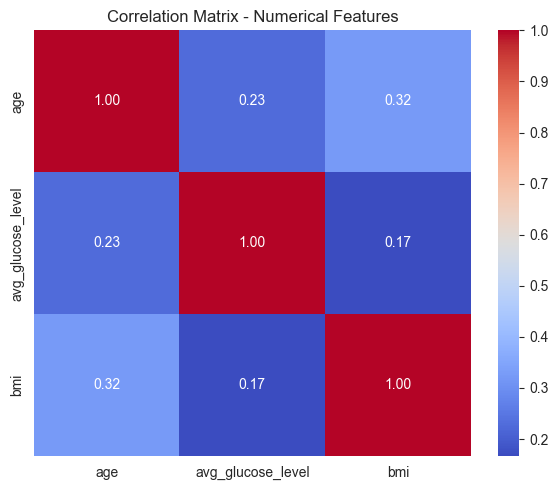

,age,avg_glucose_level,bmi
age,1.000000,0.227899,0.323864
avg_glucose_level,0.227899,1.000000,0.166490
bmi,0.323864,0.166490,1.000000


In [25]:
corr_matrix = train_df[num_cols].corr(method="pearson")

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Numerical Features")
plt.tight_layout()
plt.show()

display(corr_matrix)

### 7.2 Correlation with the target after encoding

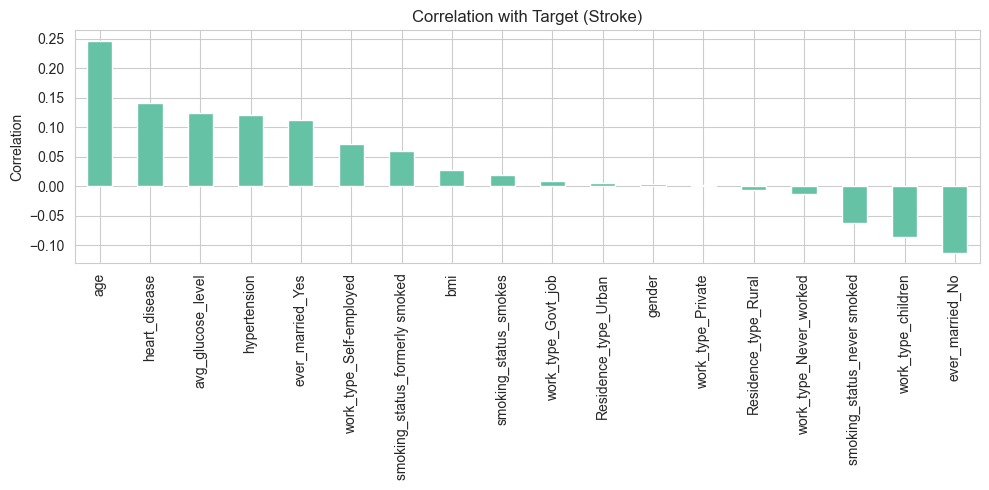

stroke                            1.000000
age                               0.246029
heart_disease                     0.141567
avg_glucose_level                 0.123389
hypertension                      0.120188
ever_married_Yes                  0.112897
work_type_Self-employed           0.071302
smoking_status_formerly smoked    0.059002
bmi                               0.027491
smoking_status_smokes             0.018129
work_type_Govt_job                0.008071
Residence_type_Urban              0.005964
gender                            0.003059
work_type_Private                 0.001501
Residence_type_Rural             -0.005964
work_type_Never_worked           -0.013119
smoking_status_never smoked      -0.061773
work_type_children               -0.085319
ever_married_No                  -0.112897
Name: stroke, dtype: float64

In [26]:
df_corr = X_train_final.copy()
df_corr["stroke"] = y_train

corr_with_target = df_corr.corr()["stroke"].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_target.drop("stroke").plot(kind="bar")
plt.title("Correlation with Target (Stroke)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

display(corr_with_target)

### 7.3 Pairwise visualization for selected numerical variables

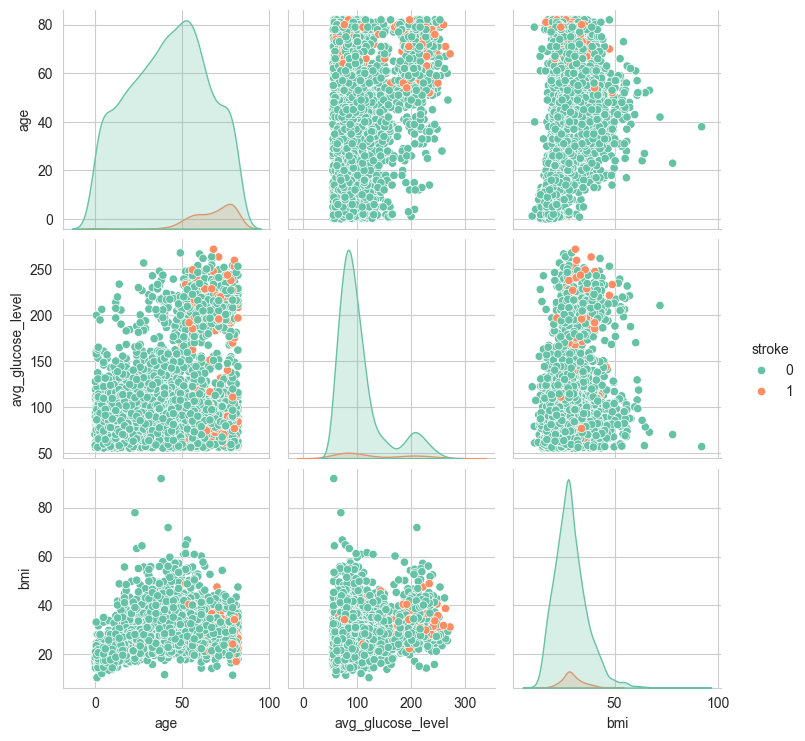

In [27]:
sns.pairplot(
    train_df[["age", "avg_glucose_level", "bmi", "stroke"]],
    hue="stroke",
    diag_kind="kde"
)
plt.show()

### 7.4 Distribution by class

The following two cells are intentionally kept, because both were present in the original notebook.


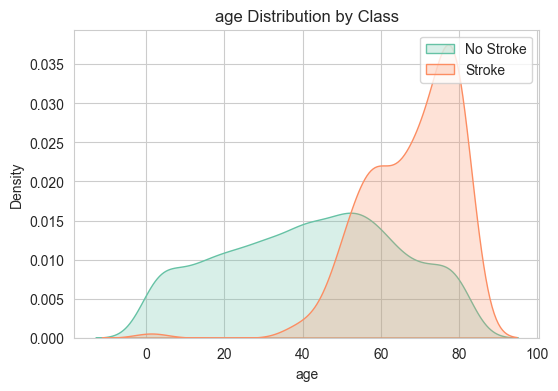

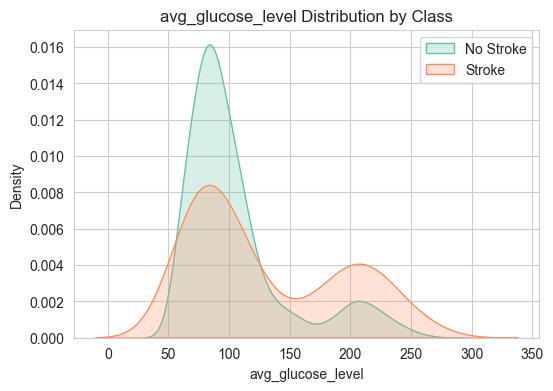

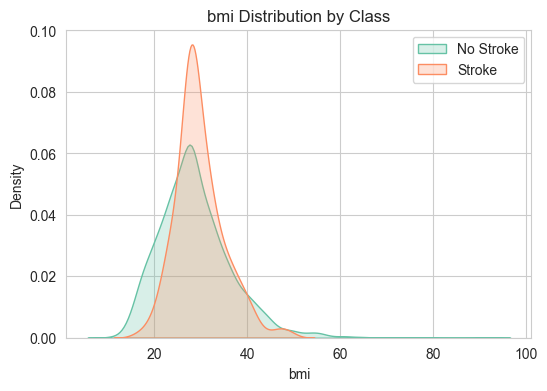

In [28]:
for col in ["age", "avg_glucose_level", "bmi"]:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(X_train[col][y_train == 0], label="No Stroke", fill=True)
    sns.kdeplot(X_train[col][y_train == 1], label="Stroke", fill=True)
    plt.title(f"{col} Distribution by Class")
    plt.legend()
    plt.show()

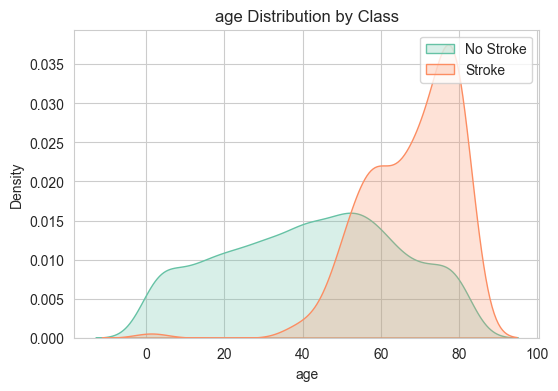

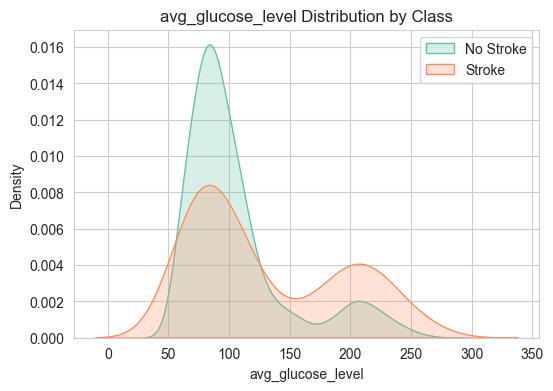

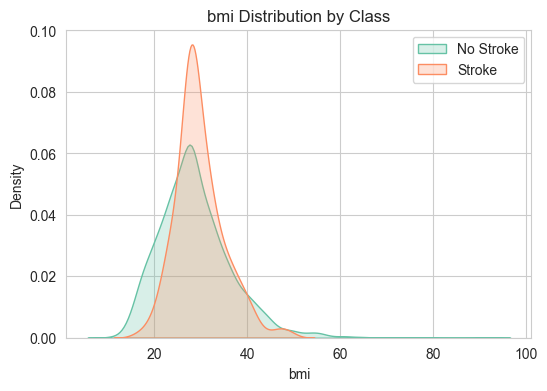

In [29]:
# Repeated class-distribution visualization retained from the original notebook
for col in ["age", "avg_glucose_level", "bmi"]:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(X_train[col][y_train == 0], label="No Stroke", fill=True)
    sns.kdeplot(X_train[col][y_train == 1], label="Stroke", fill=True)
    plt.title(f"{col} Distribution by Class")
    plt.legend()
    plt.show()

### 7.5 Numerical variables vs target — point-biserial correlation

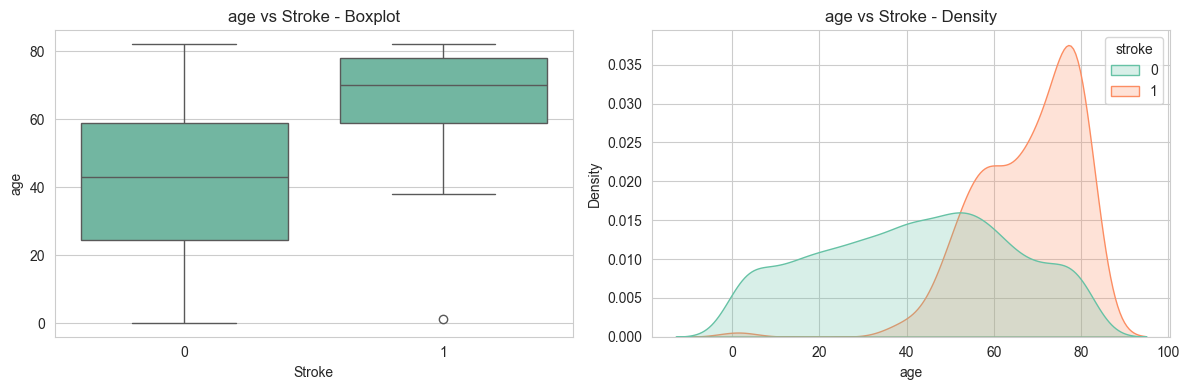

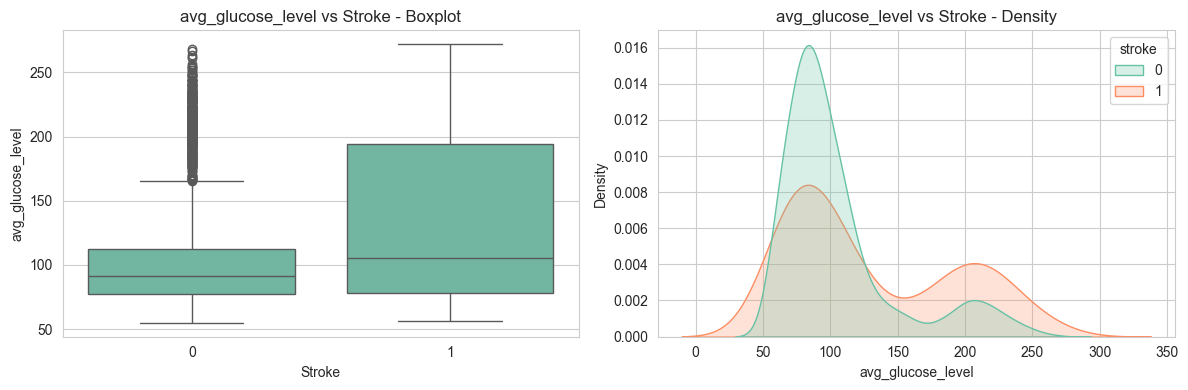

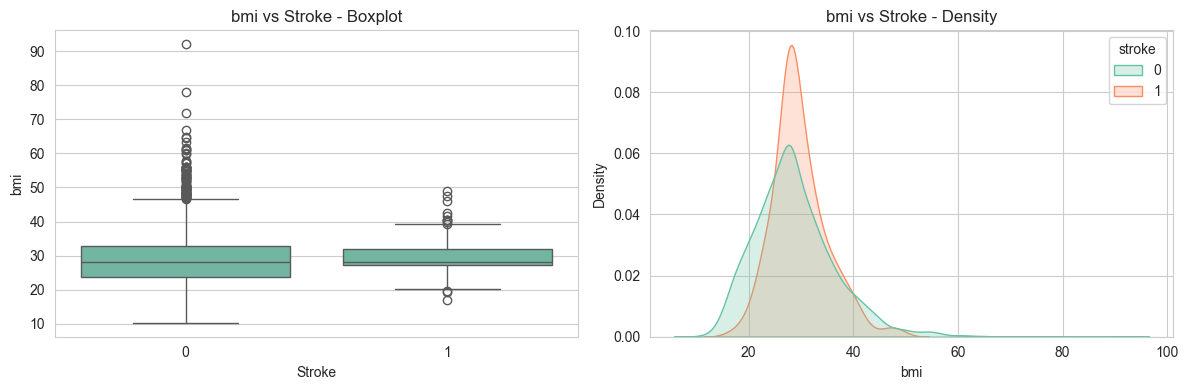

,feature,point_biserial_corr,p_value
0,age,0.246029,1.821863e-50
1,avg_glucose_level,0.123389,1.307750e-13
2,bmi,0.027491,1.001985e-01


In [30]:
from scipy.stats import pointbiserialr, chi2_contingency

num_target_results = []

for col in num_cols:
    r, p = pointbiserialr(train_df["stroke"], train_df[col])
    num_target_results.append({
        "feature": col,
        "point_biserial_corr": r,
        "p_value": p
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(data=train_df, x="stroke", y=col, ax=axes[0])
    axes[0].set_title(f"{col} vs Stroke - Boxplot")
    axes[0].set_xlabel("Stroke")
    axes[0].set_ylabel(col)

    sns.kdeplot(data=train_df, x=col, hue="stroke", fill=True, common_norm=False, ax=axes[1])
    axes[1].set_title(f"{col} vs Stroke - Density")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

num_target_df = pd.DataFrame(num_target_results).sort_values(
    by="point_biserial_corr", key=lambda s: s.abs(), ascending=False
)

display(num_target_df)

### 7.6 Binary variables vs target

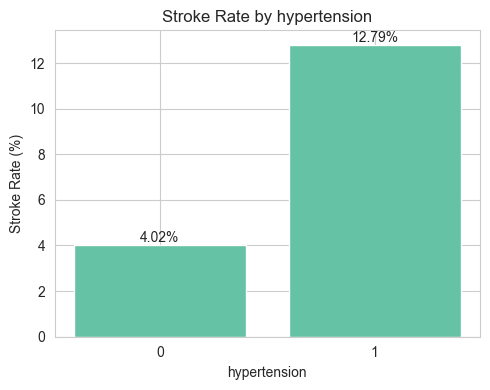


Contingency table: hypertension vs stroke


stroke,0,1
hypertension,,
0,0.959790,0.040210
1,0.872093,0.127907


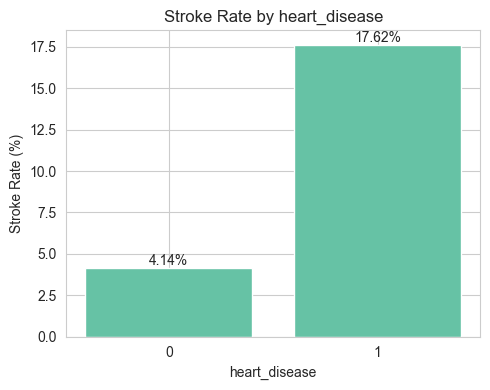


Contingency table: heart_disease vs stroke


stroke,0,1
heart_disease,,
0,0.958629,0.041371
1,0.823834,0.176166


,hypertension,mean,count,sum,stroke_rate_pct,feature,heart_disease
0,0.0,0.040210,3233,130,4.021033,hypertension,NaN
1,1.0,0.127907,344,44,12.790698,hypertension,NaN
0,NaN,0.041371,3384,140,4.137116,heart_disease,0.0
1,NaN,0.176166,193,34,17.616580,heart_disease,1.0


In [31]:
bin_target_results = []

for col in bin_cols:
    summary = train_df.groupby(col)["stroke"].agg(["mean", "count", "sum"]).reset_index()
    summary["stroke_rate_pct"] = summary["mean"] * 100
    bin_target_results.append(summary.assign(feature=col))

    plt.figure(figsize=(5, 4))
    bars = plt.bar(summary[col].astype(str), summary["stroke_rate_pct"])
    plt.title(f"Stroke Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Stroke Rate (%)")

    for bar, val in zip(bars, summary["stroke_rate_pct"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

    print(f"\nContingency table: {col} vs stroke")
    display(pd.crosstab(train_df[col], train_df["stroke"], normalize="index"))

bin_target_df = pd.concat(bin_target_results, axis=0)
display(bin_target_df)

### 7.7 Categorical variables vs target — Chi-square and Cramér's V

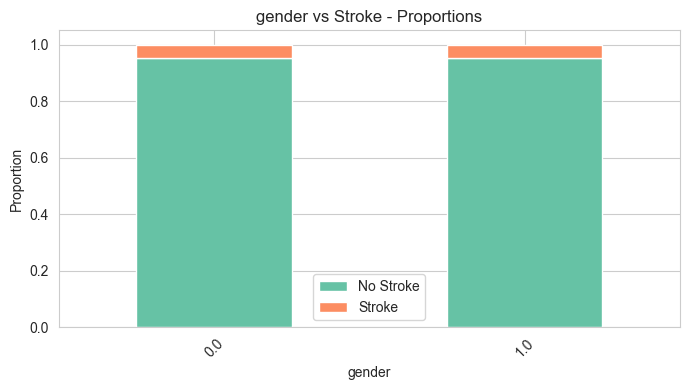

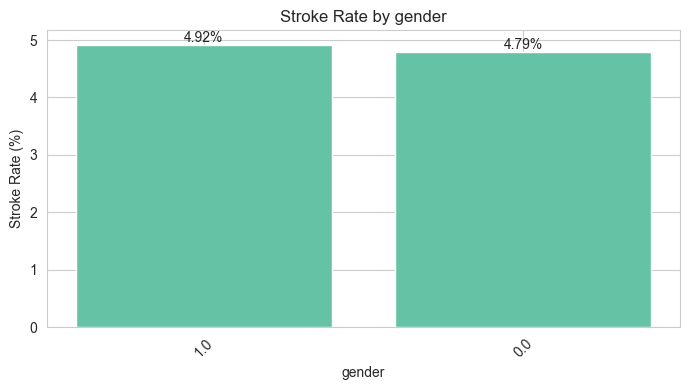

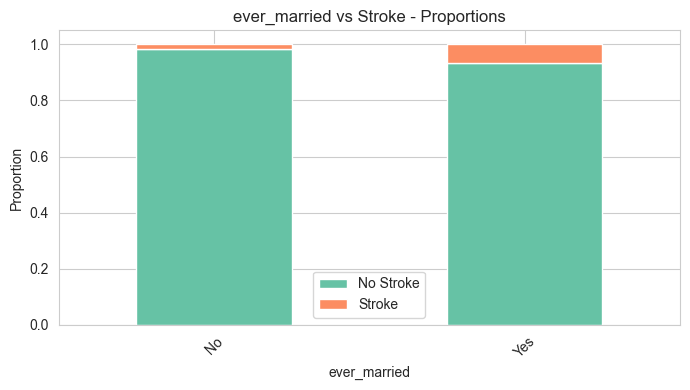

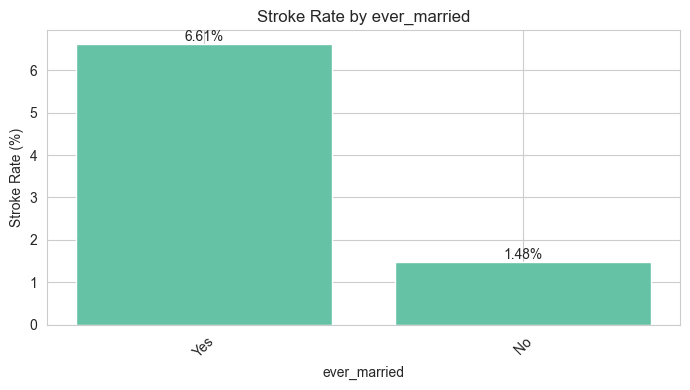

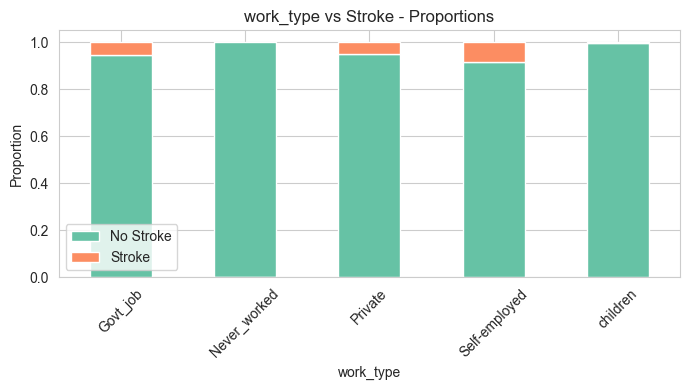

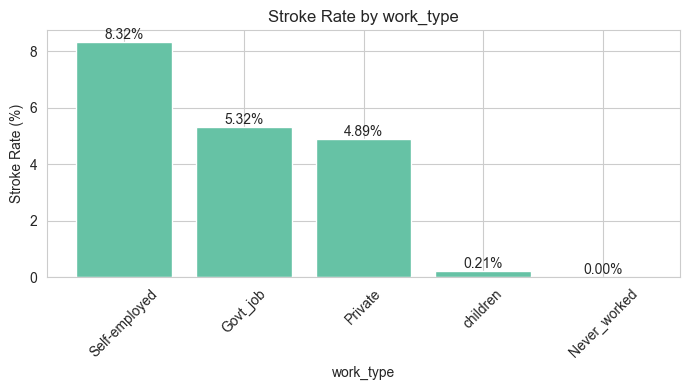

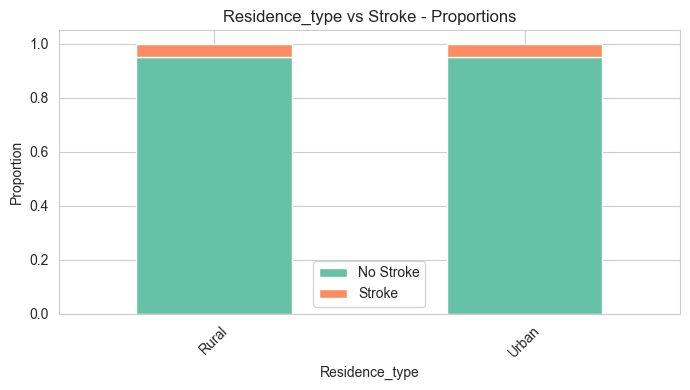

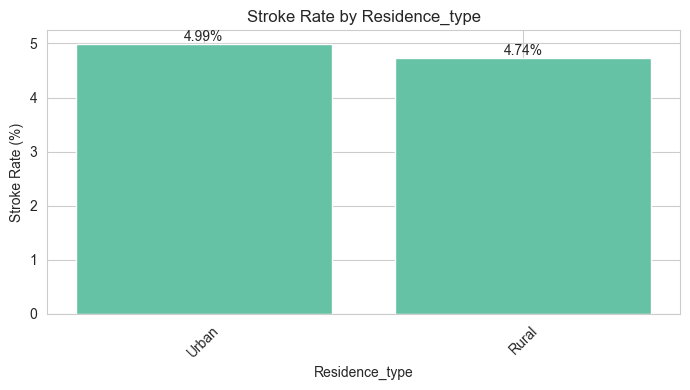

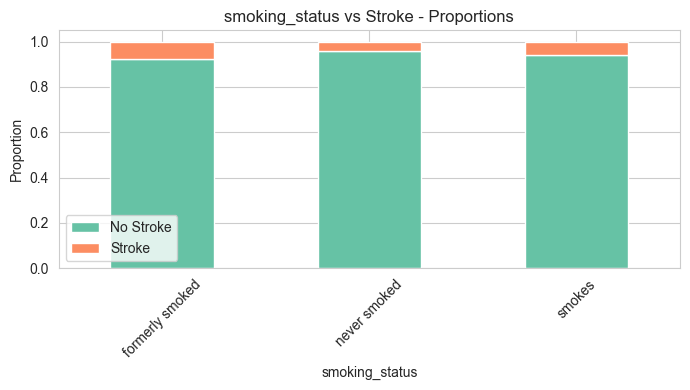

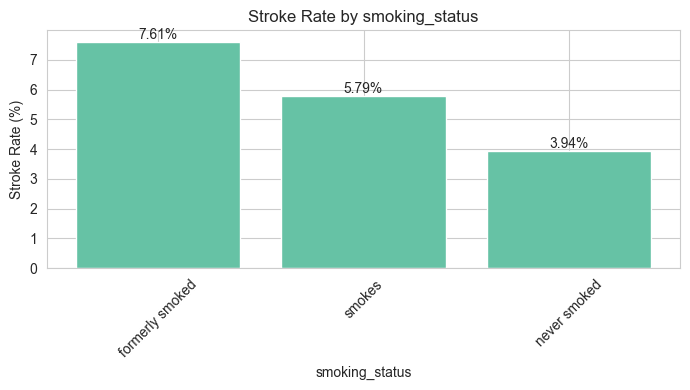

,feature,chi2_p_value,cramers_v
1,ever_married,2.556419e-11,0.110280
2,work_type,8.635430e-08,0.049165
4,smoking_status,3.887835e-04,0.043780
0,gender,9.171480e-01,0.000000
3,Residence_type,7.802566e-01,0.000000


In [32]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / max((kcorr - 1), (rcorr - 1)))

cat_target_results = []

for col in cat_cols_analysis:
    contingency = pd.crosstab(train_df[col], train_df["stroke"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    cv = cramers_v(train_df[col], train_df["stroke"])

    cat_target_results.append({
        "feature": col,
        "chi2_p_value": p,
        "cramers_v": cv
    })

    prop_table = pd.crosstab(train_df[col], train_df["stroke"], normalize="index")
    prop_table.plot(kind="bar", stacked=True, figsize=(7, 4))
    plt.title(f"{col} vs Stroke - Proportions")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(["No Stroke", "Stroke"])
    plt.tight_layout()
    plt.show()

    rate = train_df.groupby(col)["stroke"].mean().sort_values(ascending=False) * 100
    plt.figure(figsize=(7, 4))
    bars = plt.bar(rate.index.astype(str), rate.values)
    plt.title(f"Stroke Rate by {col}")
    plt.ylabel("Stroke Rate (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45)

    for bar, val in zip(bars, rate.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

cat_target_df = pd.DataFrame(cat_target_results).sort_values(
    by="cramers_v", ascending=False
)

display(cat_target_df)

### 7.8 Association matrix among categorical variables

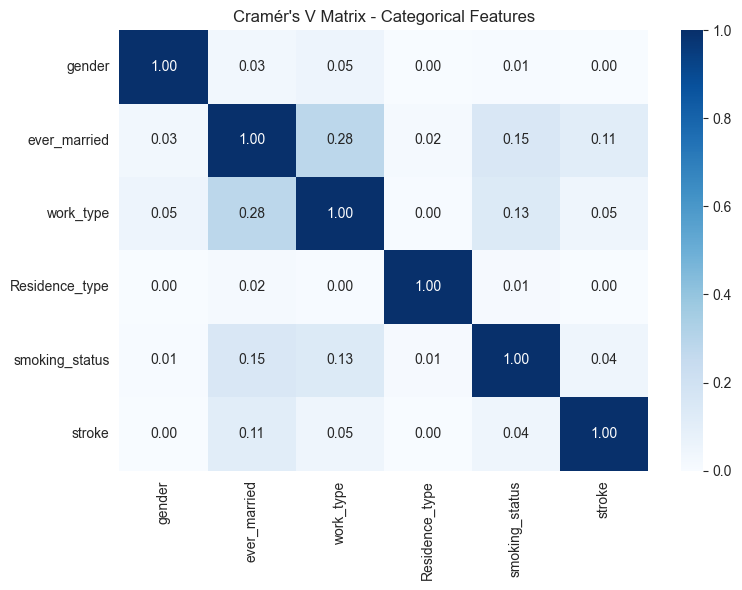

,gender,ever_married,work_type,Residence_type,smoking_status,stroke
gender,0.999424,0.034019,0.052390,0.000000,0.006497,0.000000
ever_married,0.034019,0.999377,0.284229,0.018982,0.154295,0.110280
work_type,0.052390,0.284229,1.000000,0.004209,0.132934,0.049165
Residence_type,0.000000,0.018982,0.004209,0.999441,0.013761,0.000000
smoking_status,0.006497,0.154295,0.132934,0.013761,1.000000,0.043780
stroke,0.000000,0.110280,0.049165,0.000000,0.043780,0.996979


In [33]:
cat_all = cat_cols_analysis + ["stroke"]

cramers_matrix = pd.DataFrame(index=cat_all, columns=cat_all, dtype=float)

for col1 in cat_all:
    for col2 in cat_all:
        cramers_matrix.loc[col1, col2] = cramers_v(train_df[col1], train_df[col2])

plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cramér's V Matrix - Categorical Features")
plt.tight_layout()
plt.show()

display(cramers_matrix)

### 7.9 Numerical variables vs target — direct point-biserial table retained from the original workflow

In [34]:
results = []

for col in num_cols:
    r, p = pointbiserialr(y_train, X_train[col])

    results.append({
        "feature": col,
        "correlation": r,
        "abs_correlation": abs(r),
        "p_value": p
    })

corr_df = pd.DataFrame(results).sort_values(by="abs_correlation", ascending=False)

display(corr_df)

,feature,correlation,abs_correlation,p_value
0,age,0.246029,0.246029,1.821863e-50
1,avg_glucose_level,0.123389,0.123389,1.307750e-13
2,bmi,0.027491,0.027491,1.001985e-01


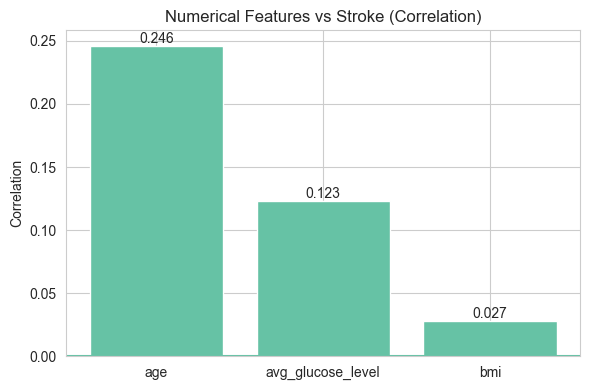

In [35]:
plt.figure(figsize=(6, 4))

bars = plt.bar(corr_df["feature"], corr_df["correlation"])

plt.title("Numerical Features vs Stroke (Correlation)")
plt.ylabel("Correlation")
plt.axhline(0)

for bar, val in zip(bars, corr_df["correlation"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 7.10 Non-linear / non-parametric association: Spearman correlation

In [36]:
results_spearman = []

for col in ["age", "avg_glucose_level", "bmi"]:
    corr = pd.Series(X_train[col]).corr(y_train, method="spearman")

    results_spearman.append({
        "feature": col,
        "spearman_corr": corr,
        "abs_corr": abs(corr)
    })

spearman_df = pd.DataFrame(results_spearman).sort_values(
    by="abs_corr", ascending=False
)

display(spearman_df)

,feature,spearman_corr,abs_corr
0,age,0.251601,0.251601
1,avg_glucose_level,0.070342,0.070342
2,bmi,0.049305,0.049305


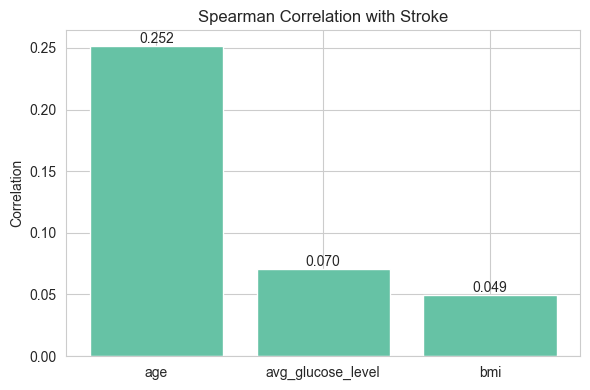

In [37]:
plt.figure(figsize=(6, 4))

bars = plt.bar(spearman_df["feature"], spearman_df["spearman_corr"])

plt.title("Spearman Correlation with Stroke")
plt.ylabel("Correlation")

for bar, val in zip(bars, spearman_df["spearman_corr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 7.11 Non-linear association: mutual information

In [38]:
from sklearn.feature_selection import mutual_info_classif

X_num = X_train[["age", "avg_glucose_level", "bmi"]]

mi = mutual_info_classif(X_num, y_train, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_num.columns,
    "mutual_info": mi
}).sort_values(by="mutual_info", ascending=False)

display(mi_df)

,feature,mutual_info
0,age,0.041748
2,bmi,0.012949
1,avg_glucose_level,0.005168


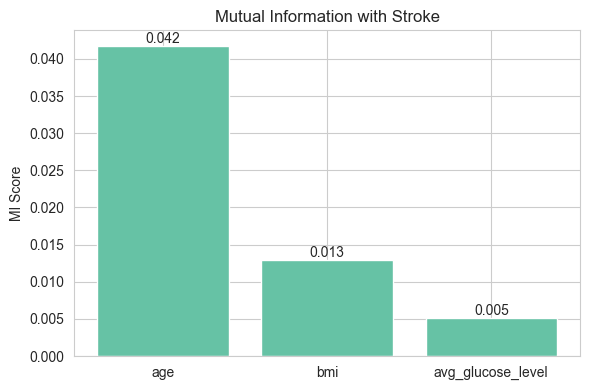

In [39]:
plt.figure(figsize=(6, 4))

bars = plt.bar(mi_df["feature"], mi_df["mutual_info"])

plt.title("Mutual Information with Stroke")
plt.ylabel("MI Score")

for bar, val in zip(bars, mi_df["mutual_info"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 7.12 Global summary of association with the target

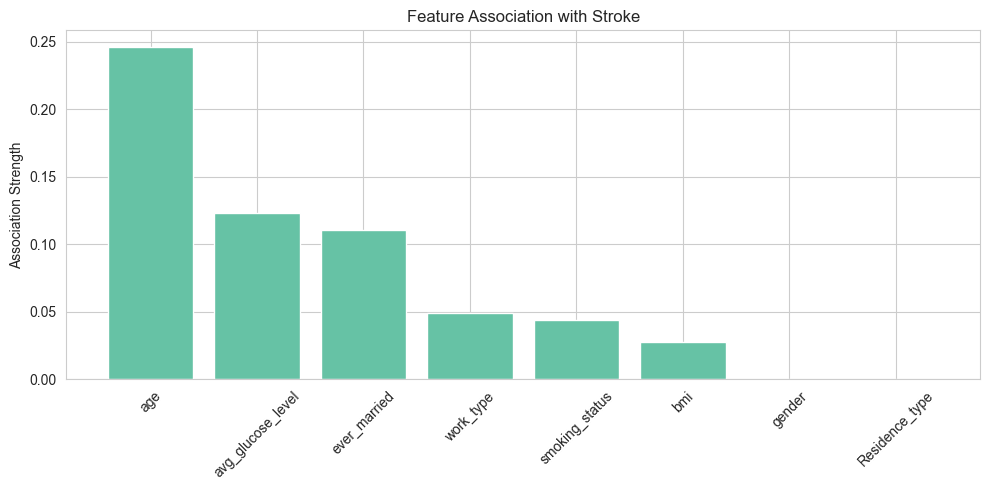

,feature,association_metric,metric_type
0,age,0.246029,Point-biserial
1,avg_glucose_level,0.123389,Point-biserial
1,ever_married,0.110280,Cramér's V
2,work_type,0.049165,Cramér's V
4,smoking_status,0.043780,Cramér's V
2,bmi,0.027491,Point-biserial
0,gender,0.000000,Cramér's V
3,Residence_type,0.000000,Cramér's V


In [40]:
num_summary = num_target_df[["feature", "point_biserial_corr"]].copy()
num_summary["association_metric"] = num_summary["point_biserial_corr"].abs()
num_summary["metric_type"] = "Point-biserial"

cat_summary = cat_target_df[["feature", "cramers_v"]].copy()
cat_summary = cat_summary.rename(columns={"cramers_v": "association_metric"})
cat_summary["metric_type"] = "Cramér's V"

global_summary = pd.concat([
    num_summary[["feature", "association_metric", "metric_type"]],
    cat_summary[["feature", "association_metric", "metric_type"]]
], axis=0).sort_values(by="association_metric", ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(global_summary["feature"], global_summary["association_metric"])
plt.title("Feature Association with Stroke")
plt.ylabel("Association Strength")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(global_summary)

## 8. Scaling for future models

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)

print("Scaling completed.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

Scaling completed.
X_train_scaled shape: (3577, 18)
X_val_scaled shape: (1533, 18)


## 9. Summary

This notebook now contains the same analytical content as the original workflow, but presented in a more structured order:
1. Data loading and split.
2. EDA on the training set.
3. Focused missing-data and `"Unknown"` analysis.
4. Leakage-safe preprocessing.
5. Encoded and scaled matrices ready for modeling.
6. Correlation and association analysis using multiple complementary metrics.
